#Customer Support Router Agentic RAG System

![](https://i.imgur.com/Em0lzai.png)


This project builds a smart customer support system using AI agents and Retrieval-Augmented Generation (RAG). It uses a GROQ-powered model to understand user queries, check their tone, and send them to the right place for a response.

## How It Works
**1. Query Understanding**

The system uses a GROQ-based model to:
  Identify the query type (billing, technical, or general)
  Detect user sentiment (positive, neutral, or negative)

**2. Smart Routing**
Based on the query type and sentiment:
  Negative sentiment → Sent to a human agent
  Billing queries → Billing response
  Technical issues → Technical response
  General questions → General response

**3. Knowledge Base (RAG)**
The system connects to a vector database to:
  Find relevant information
  Generate accurate, up-to-date answers using RAG

**4. Escalation**
If the user is unhappy (negative sentiment), the system sends the query to a human for better support.

## Summary

This system makes customer support faster and smarter by automatically understanding queries, retrieving the right information, and routing them correctly.

In [1]:
!pip install langchain==1.2.15 langchain-community==0.4.1 langchain_openai==1.1.14 langgraph==1.1.8 langchain-groq==1.1.2 langchain-huggingface==1.2.2 sentence-transformers==5.4.1 langchain-chroma==1.1.0 --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.7/88.7 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 173.7/173.7 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.3/571.3 kB 32.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 69.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 45.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.1/515.1 kB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 73.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/

In [2]:
!pip install ipywidgets jupyter-ui-poll --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 25.8 MB/s eta 0:00:00


## Configure API Key

In [3]:
from google.colab import userdata
GROQ_API_KEY = userdata.get('GROQ_API_KEY')

## Load Knowledge Base

In [4]:
!gdown 1CWHutosAcJ6fiddQW5ogvg7NgLstZJ9j

Downloading...
From: https://drive.google.com/uc?id=1CWHutosAcJ6fiddQW5ogvg7NgLstZJ9j
To: /content/router_agent_documents.json
100% 7.99k/7.99k [00:00<00:00, 24.2MB/s]


In [5]:
import json
with open("/content/router_agent_documents.json","r") as f:
  knowledge_base = json.load(f)

In [6]:
from langchain_core.documents import Document
from tqdm import tqdm
processed_docs = []

for doc in tqdm(knowledge_base):
  metadata = doc["metadata"]
  data = doc["text"]
  processed_docs.append(Document(page_content=data,metadata=metadata))

processed_docs[:3]

100%|██████████| 30/30 [00:00<00:00, 45939.80it/s]


[Document(metadata={'category': 'technical'}, page_content='Question: How do I integrate your AI product with my existing CRM system? Answer: You can integrate our AI product with your CRM using our API. Refer to the API documentation available on our website for step-by-step guidance.'),
 Document(metadata={'category': 'technical'}, page_content='Question: What programming languages are supported by your SDK? Answer: Our SDK supports Python, Java, and JavaScript. Additional language support is planned for future updates.'),
 Document(metadata={'category': 'technical'}, page_content='Question: Can your AI models run on-premise? Answer: Yes, our AI models can be deployed on-premise. We provide deployment guides for various environments.')]

In [7]:
categories = set([doc.metadata["category"] for doc in processed_docs])
categories

{'billing', 'general', 'technical'}

In [8]:
billing_data = [doc for doc in processed_docs if doc.metadata["category"] == "billing"]
general_data = [doc for doc in processed_docs if doc.metadata["category"] == "general"]
technical_data = [doc for doc in processed_docs if doc.metadata["category"] == "technical"]

## Create a Vector Databases

In [9]:
from langchain_huggingface import HuggingFaceEmbeddings

embed_model = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [10]:
from langchain_chroma import Chroma

billing_db = Chroma.from_documents(
    documents=billing_data,
    embedding=embed_model,
    collection_name="billing_database",
    collection_metadata={"hnsw:space": "cosine"},
    persist_directory="/content/knowledge-bases"
)

technical_db = Chroma.from_documents(
    documents=technical_data,
    embedding=embed_model,
    collection_name="technical_database",
    collection_metadata={"hnsw:space": "cosine"},
    persist_directory="/content/knowledge-bases"
)

general_db = Chroma.from_documents(
    documents=general_data,
    embedding=embed_model,
    collection_name="general_database",
    collection_metadata={"hnsw:space": "cosine"},
    persist_directory="/content/knowledge-bases"
)


In [11]:
billing_retriever = billing_db.as_retriever(search_type="similarity_score_threshold",
                                            search_kwargs={"k": 3, "score_threshold": 0.2})

technical_retriever = technical_db.as_retriever(search_type="similarity_score_threshold",
                                               search_kwargs={"k": 3, "score_threshold": 0.2})

general_retriever = general_db.as_retriever(search_type="similarity_score_threshold",
                                            search_kwargs={"k": 3, "score_threshold": 0.2})

In [12]:
query = "What is refund policy?"
billing_retriever.invoke(query)


[Document(id='a0e1a7a1-e9ce-4ea0-a237-5215220bf62f', metadata={'category': 'billing'}, page_content='Question: Do you provide refunds for unused subscription periods? Answer: Refunds are provided based on our refund policy. Please refer to our Terms and Conditions for more details.'),
 Document(id='947b984d-ed1b-48e1-b6f4-83356555acdf', metadata={'category': 'billing'}, page_content='Question: What payment methods do you accept? Answer: We accept credit cards, PayPal, and wire transfers for corporate accounts.'),
 Document(id='bd61a5ad-796d-4322-b6ac-c1f386f9e4f5', metadata={'category': 'billing'}, page_content='Question: Do you charge taxes on the subscription? Answer: Applicable taxes are calculated based on your location and displayed during checkout.')]

## Define the Agent State Schema

We create a `CustomerSupportState` typed dictionary to keep track of each interaction:
- **customer_query**: The text of the customer's question
- **query_category**: Technical, Billing, or General (used for routing)
- **query_sentiment**: Positive, Neutral, or Negative (used for routing)
- **final_response**: The system's response to the customer
- **escalation_cust_info**: The customer details when input in the escalation form

In [13]:
from typing import TypedDict, Literal
from pydantic import BaseModel

class CustomerSupportState(TypedDict):
  customer_query: str
  query_category: str
  query_sentiment: str
  final_response: str
  escalation_cust_info: str

class QueryCategory(BaseModel):
  categorized_topic: Literal["Billing", "Technical", "General"]

class QuerySentiment(BaseModel):
  sentiment: Literal["Positive", "Neutral", "Negative"]

## Create Node Functions

Each function below represents a stage in processing a customer inquiry:

1. **categorize_inquiry**: Classifies the query into Technical, Billing, or General.
2. **analyze_inquiry_sentiment**: Determines if the sentiment is Positive, Neutral, or Negative.
3. **generate_technical_response**: Produces a response for technical issues.
4. **generate_billing_response**: Produces a response for billing questions.
5. **generate_general_response**: Produces a response for general queries.
6. **accept_user_input_escalation**: Collects additional input from the user when a negative sentiment is detected to facilitate escalation to a human support agent.
6. **escalate_to_human_agent**: Escalates the query and submitted form details to a human agent for personalized resolution.
7. **determine_route**: Routes the inquiry to the appropriate response node based on category and sentiment.

In [14]:
from langchain_groq import ChatGroq

llm = ChatGroq(model="llama-3.3-70b-versatile", temperature=0, api_key=GROQ_API_KEY)


In [15]:
def categorize_inquiry(support_state: CustomerSupportState) -> CustomerSupportState:
  """
  Classify the customer query into Technical, Billing, General
  """
  query = support_state["customer_query"]
  ROUTE_CATEGORY_PROMPT="""
                        Act as a customer support agent trying to best categorize the customer query.
                               You are an agent for an AI products and hardware company.

                               Please read the customer query below and
                               determine the best category from the following list:

                               'Technical', 'Billing', or 'General'.

                               Remember:
                                - Technical queries will focus more on technical aspects like AI models, hardware, software related queries etc.
                                - General queries will focus more on general aspects like contacting support, finding things, policies etc.
                                - Billing queries will focus more on payment and purchase related aspects

                                Return just the category name (from one of the above)

                                Query:
                                {customer_query}
                          """
  prompt = ROUTE_CATEGORY_PROMPT.format(customer_query=query)
  route_category = llm.with_structured_output(QueryCategory).invoke(prompt)

  return {
      "query_category": route_category.categorized_topic
  }

In [16]:
categorize_inquiry({"customer_query":"Do you provide pretrained models?"})

{'query_category': 'Technical'}

In [17]:
categorize_inquiry({"customer_query": "what payment methods are accepted?"})

{'query_category': 'Billing'}

In [18]:
def analyze_inquiry_sentiment(support_state: CustomerSupportState) -> CustomerSupportState:
  """
  Analyze the sentiment of the customer query as Positive, Neutral, or Negative
  """
  query = support_state["customer_query"]
  SENTIMENT_CATEGORY_PROMPT = """Act as a customer support agent trying to best categorize the customer query's sentiment.
                                   You are an agent for an AI products and hardware company.

                                   Please read the customer query below,
                                   analyze its sentiment which should be one from the following list:

                                   'Positive', 'Neutral', or 'Negative'.

                                   Return just the sentiment (from one of the above)

                                   Query:
                                   {customer_query}
                                """
  prompt = SENTIMENT_CATEGORY_PROMPT.format(customer_query=query)
  sentiment_category = llm.with_structured_output(QuerySentiment).invoke(prompt)
  return {
      "query_sentiment": sentiment_category.sentiment
  }

In [19]:
analyze_inquiry_sentiment({"customer_query": "what is your refund policy?"})

{'query_sentiment': 'Neutral'}

In [20]:
analyze_inquiry_sentiment({"customer_query": "what is your refund policy? I am really fed up with this product and need to refund it"})

{'query_sentiment': 'Negative'}

In [21]:
from langchain_core.prompts import ChatPromptTemplate
from typing import Dict

def generate_technical_response(support_state: CustomerSupportState) -> CustomerSupportState:
  """
  Provide a technical support response by combining knowledge from the vector store and LLM.
  """
  query = support_state["customer_query"]

  relevant_docs = technical_retriever.invoke(query)
  retrieved_content = "\n\n".join(doc.page_content for doc in relevant_docs)

  prompt = ChatPromptTemplate.from_template(
        """
        Craft a clear and detailed technical support response for the following customer query.
        Use the provided knowledge base information to enrich your response.
        Provide just the response content - do not add any boilerplate template information.
        In case there is no knowledge base information or you do not know the answer just say:

        Apologies I was not able to answer your question, please reach out to +1-xxx-xxxx

        Customer Query:
        {customer_query}

        Relevant Knowledge Base Information:
        {retrieved_content}
        """
    )

  chain = prompt | llm
  tech_reply = chain.invoke({"customer_query": query, "retrieved_content": retrieved_content}).content
  return {
      "final_response": tech_reply}

In [22]:
generate_technical_response({"customer_query": "do you support on-prem models?",
                             "query_category": "Technical"})

{'final_response': "Yes, we support on-prem models. Our AI models can be deployed on-premise, and we provide deployment guides for various environments to ensure a smooth setup process. This allows you to maintain control over your data and infrastructure while still leveraging the power of our pre-trained models for tasks such as NLP, computer vision, and recommendation systems. Additionally, you have the flexibility to fine-tune our models using your custom datasets to further tailor them to your specific needs. If you need assistance with the deployment or have questions about the process, please let us know and we'll be happy to help."}

In [23]:

def generate_billing_response(support_state: CustomerSupportState) -> CustomerSupportState:
  """
  Provide a billing response by combining knowledge from the vector store and LLM.
  """
  query = support_state["customer_query"]

  relevant_docs = billing_retriever.invoke(query)
  retrieved_content = "\n\n".join(doc.page_content for doc in relevant_docs)

  prompt = ChatPromptTemplate.from_template(
        """
        Craft a clear and detailed billing support response for the following customer query.
        Use the provided knowledge base information to enrich your response.
        Provide just the response content - do not add any boilerplate template information.
        In case there is no knowledge base information or you do not know the answer just say:

        Apologies I was not able to answer your question, please reach out to +1-xxx-xxxx

        Customer Query:
        {customer_query}

        Relevant Knowledge Base Information:
        {retrieved_content}
        """
    )

  chain = prompt | llm
  billing_reply = chain.invoke({"customer_query": query, "retrieved_content": retrieved_content}).content
  return {
      "final_response": billing_reply}

In [24]:
def generate_general_response(support_state: CustomerSupportState) -> CustomerSupportState:
    """
    Provide a general support response by combining knowledge from the vector store and LLM.
    """
    query = support_state["customer_query"]

    relevant_docs = general_retriever.invoke(query)
    retrieved_content = "\n\n".join(doc.page_content for doc in relevant_docs)

    prompt = ChatPromptTemplate.from_template(
        """
        Craft a clear and detailed general support response for the following customer query.
        Use the provided knowledge base information to enrich your response.
        Provide just the response content - do not add any boilerplate template information.
        In case there is no knowledge base information or you do not know the answer just say:

        Apologies I was not able to answer your question, please reach out to +1-xxx-xxxx

        Customer Query:
        {customer_query}

        Relevant Knowledge Base Information:
        {retrieved_content}
        """
    )

    chain = prompt | llm
    general_reply = chain.invoke({
        "customer_query": query,
        "retrieved_content": retrieved_content
    }).content

    return {
        "final_response": general_reply
    }


### Create the accept_user_input_escalation function

![](https://i.imgur.com/nwTR2ce.png)

Collects additional input from the user when a negative sentiment is detected to facilitate escalation to a human support agent.

This function opens up a simple form using Jupyter widgets as a User Interface (UI), accepts information from the user in the UI and saves it in the agent state to be used later. Example shown below here:

![](https://i.imgur.com/feZqjwj.png)

In [25]:
import ipywidgets as widgets
from IPython.display import display
from jupyter_ui_poll import ui_events
import time

def accept_user_input_escalation(support_state: CustomerSupportState) -> CustomerSupportState:

    global form_submitted  # status variable to track form submission
    form_submitted = False # initially form hasn't been submitted

    # UI Header: A simple HTML element to label the form
    header = widgets.HTML("<h3>Escalation Form - Please enter your details below:</h3>")

    # Text input fields to collect user information
    input1 = widgets.Text(description='Name:')     # User's full name
    input2 = widgets.Text(description='Number:')   # Contact number
    input3 = widgets.Text(description='Email:')    # Email address

    # Dictionary to store form responses after submission
    result = {}

    # Callback function to be triggered when the Submit button is clicked
    def on_submit(submit_button):
        global form_submitted
        form_submitted = True  # Mark the form as submitted
        # Store user inputs into the result dictionary
        result['name'] = input1.value
        result['number'] = input2.value
        result['email'] = input3.value
        # Provide visual feedback that form is submitted
        submit_button.description = '👍'

    # Submit button widget setup
    submit_button = widgets.Button(description="Submit")
    submit_button.on_click(on_submit)  # Attach callback to button

    # Combine all widgets into a vertical layout box
    vbox = widgets.VBox([header, input1, input2, input3, submit_button])
    display(vbox)  # Render the form in the notebook interface

    # Keep polling UI events until the form is submitted
    with ui_events() as poll:
        while form_submitted is False:
            poll(5)               # Listen for UI events
            print('.', end='')   # Show a dot to indicate waiting for input from user
            time.sleep(0.3)      # Slight delay to reduce CPU usage

    # Return updated agent state with captured user info for escalation
    return {
        'escalation_cust_info': result
    }


In [26]:
def escalate_to_human_agent(support_state: CustomerSupportState) -> CustomerSupportState:

    # get the customer info from agent state which they entered in the form
    escalation_cust_info = support_state['escalation_cust_info']
    # the following response will be shown to the user and can also be sent (customer form inputs) to your human support agents
    response = ("Apologies, " + escalation_cust_info['name'] +
                ",  we are really sorry! Someone from our team will be reaching out to via email shortly at "+
                escalation_cust_info['email'] + " and if needed we will also be calling you at: " +
                escalation_cust_info['number'] + " to help you out!")

    # NOTE: You can always add custom code here to call specific APIs like whatsapp or email etc to notify your human support agents

    return {
        "final_response": response
    }

## Build and Compile the Agent Workflow

Construct a LangGraph Agentic workflow with the nodes defined above:
1. **categorize_inquiry** → **analyze_inquiry_sentiment** → **route** to the proper response node.
2. If negative, escalate to a human agent by filling in the customer escalation form first.
3. Otherwise, produce an appropriate response (technical, billing, or general).

In [27]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver

# Create the graph with our typed state
customer_support_graph = StateGraph(CustomerSupportState)

# Add nodes for each function
customer_support_graph.add_node("categorize_inquiry", categorize_inquiry)
customer_support_graph.add_node("analyze_inquiry_sentiment", analyze_inquiry_sentiment)
customer_support_graph.add_node("generate_technical_response", generate_technical_response)
customer_support_graph.add_node("generate_billing_response", generate_billing_response)
customer_support_graph.add_node("generate_general_response", generate_general_response)
customer_support_graph.add_node("accept_user_input_escalation", accept_user_input_escalation)
customer_support_graph.add_node("escalate_to_human_agent", escalate_to_human_agent)

# Add edges to represent the processing flow
customer_support_graph.add_edge("categorize_inquiry", "analyze_inquiry_sentiment")

# routing function
def determine_route(support_state: CustomerSupportState) -> str:
    """
    Route the inquiry based on sentiment and category.
    """
    if support_state["query_sentiment"] == "Negative":
        return "human_escalate_route"
    elif support_state["query_category"] == "Technical":
        return "technical_rag_route"
    elif support_state["query_category"] == "Billing":
        return "billing_rag_route"
    else:
        return "general_rag_route"

customer_support_graph.add_conditional_edges(
    "analyze_inquiry_sentiment",
    determine_route,
    {
        "human_escalate_route": "accept_user_input_escalation",
        "technical_rag_route": "generate_technical_response",
        "billing_rag_route": "generate_billing_response",
        "general_rag_route": "generate_general_response"
    }
)

customer_support_graph.add_edge("accept_user_input_escalation", "escalate_to_human_agent")

# All terminal nodes lead to the END
customer_support_graph.add_edge("generate_technical_response", END)
customer_support_graph.add_edge("generate_billing_response", END)
customer_support_graph.add_edge("generate_general_response", END)
customer_support_graph.add_edge("escalate_to_human_agent", END)

# Set the entry point for the workflow
customer_support_graph.set_entry_point("categorize_inquiry")

# Compile the graph into a runnable agent
memory = MemorySaver()
form_submitted = False
compiled_support_agent = customer_support_graph.compile(checkpointer=memory)

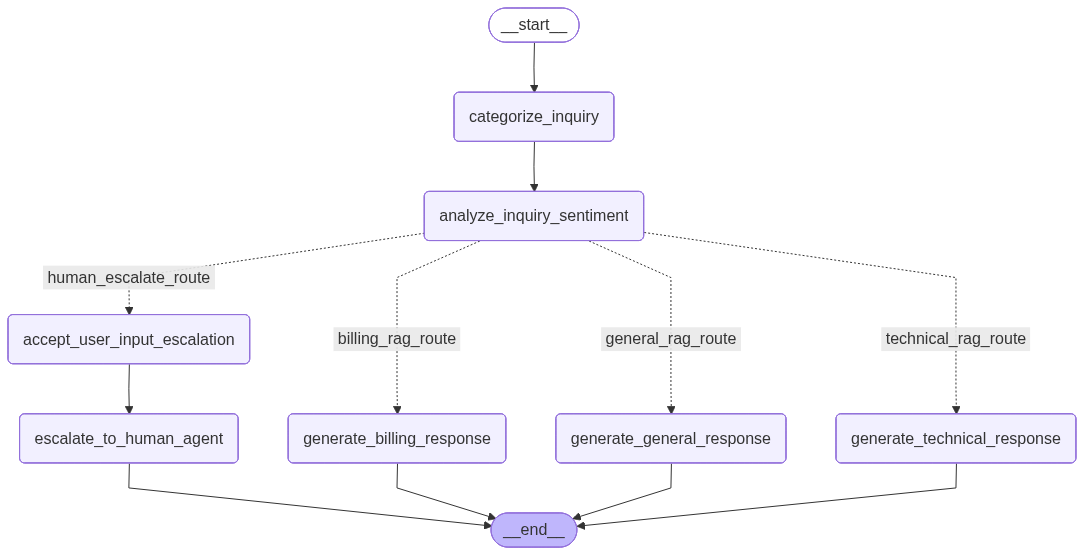

In [28]:
from IPython.display import display, Image, Markdown
display(Image(compiled_support_agent.get_graph().draw_mermaid_png()))

## Helper Function to Run the Agent Workflow


In [29]:
def call_support_agent(agent, prompt, user_session_id, verbose=False):
    events = agent.stream(
        {"customer_query": prompt}, # initial state of the agent
        {"configurable": {"thread_id": user_session_id}},
        stream_mode="values",
    )

    print('Running Agent. Please wait...')
    for event in events:
        if verbose:
                print(event)

    print('\nAgent Response:')
    display(Markdown(event['final_response'].replace('$', '\$')))

<>:14: SyntaxWarning: invalid escape sequence '\$'
<>:14: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipykernel_587/1976429717.py:14: SyntaxWarning: invalid escape sequence '\$'
  display(Markdown(event['final_response'].replace('$', '\$')))


In [30]:
uid = 'jim001'
query = "do you support pre-trained models?"
call_support_agent(agent=compiled_support_agent,
                   prompt=query,
                   user_session_id=uid,
                   verbose=True)

Running Agent. Please wait...
{'customer_query': 'do you support pre-trained models?'}
{'customer_query': 'do you support pre-trained models?', 'query_category': 'Technical'}
{'customer_query': 'do you support pre-trained models?', 'query_category': 'Technical', 'query_sentiment': 'Neutral'}
{'customer_query': 'do you support pre-trained models?', 'query_category': 'Technical', 'query_sentiment': 'Neutral', 'final_response': "We do support pre-trained models. In fact, we offer a range of pre-trained models for various use cases such as Natural Language Processing (NLP), computer vision, and recommendation systems. These models are designed to provide a solid foundation for your projects, and you can further fine-tune them using your custom datasets to suit your specific needs. Additionally, our pre-trained models can be deployed on-premise, and we provide detailed deployment guides for various environments to ensure a seamless integration. If you have any specific requirements or would

We do support pre-trained models. In fact, we offer a range of pre-trained models for various use cases such as Natural Language Processing (NLP), computer vision, and recommendation systems. These models are designed to provide a solid foundation for your projects, and you can further fine-tune them using your custom datasets to suit your specific needs. Additionally, our pre-trained models can be deployed on-premise, and we provide detailed deployment guides for various environments to ensure a seamless integration. If you have any specific requirements or would like to know more about our pre-trained models, please let us know and we'll be happy to assist you.

In [31]:
query = "I'm fed up with this faulty hardware, I need a refund"
call_support_agent(agent=compiled_support_agent,
                   prompt=query,
                   user_session_id=uid,
                   verbose=True)

Running Agent. Please wait...
{'customer_query': "I'm fed up with this faulty hardware, I need a refund", 'query_category': 'Technical', 'query_sentiment': 'Neutral', 'final_response': "We do support pre-trained models. In fact, we offer a range of pre-trained models for various use cases such as Natural Language Processing (NLP), computer vision, and recommendation systems. These models are designed to provide a solid foundation for your projects, and you can further fine-tune them using your custom datasets to suit your specific needs. Additionally, our pre-trained models can be deployed on-premise, and we provide detailed deployment guides for various environments to ensure a seamless integration. If you have any specific requirements or would like to know more about our pre-trained models, please let us know and we'll be happy to assist you."}
{'customer_query': "I'm fed up with this faulty hardware, I need a refund", 'query_category': 'Billing', 'query_sentiment': 'Neutral', 'fina

............................................................................{'customer_query': "I'm fed up with this faulty hardware, I need a refund", 'query_category': 'Billing', 'query_sentiment': 'Negative', 'final_response': "We do support pre-trained models. In fact, we offer a range of pre-trained models for various use cases such as Natural Language Processing (NLP), computer vision, and recommendation systems. These models are designed to provide a solid foundation for your projects, and you can further fine-tune them using your custom datasets to suit your specific needs. Additionally, our pre-trained models can be deployed on-premise, and we provide detailed deployment guides for various environments to ensure a seamless integration. If you have any specific requirements or would like to know more about our pre-trained models, please let us know and we'll be happy to assist you.", 'escalation_cust_info': {'name': 'HA', 'number': '00000', 'email': 'ha@gmail.com'}}
{'customer_

Apologies, HA,  we are really sorry! Someone from our team will be reaching out to via email shortly at ha@gmail.com and if needed we will also be calling you at: 00000 to help you out!